# 0g — Build unified LGR5 status & label columns

* **Developed by:** Anna Maguza
* **Affilation:** CellZome, a GSK company
* **Created date:** 2026-05-17
* **Last modified date:** 2026-05-17

Builds two strict-provenance columns on every downstream object:

- **`lgr5_status`** — `LGR5+` only for FACS-sorted positives + RNAscope-validated Ishikawa 108; `LGR5-` for FACS-sorted negatives; `LGR5_unknown` otherwise. Renames existing `unknown` -> `LGR5_unknown`.
- **`lgr5_label`** — fused label for scANVI/scPoli: atlas + Ishikawa unsorted -> `cell_states`; FACS LGR5+ / RNAscope+ Ishikawa -> `LGR5+`; FACS LGR5- -> `LGR5-`; everything else without `cell_states` -> `Unknown`.

Updates Object A (`object_a_human.h5ad`), Object B orth (`object_b_cross_species_orth.h5ad`), the three integrated Object A objects (scVI / scANVI / scPoli), and adds `lgr5_status` to the atlas object. Records the change in `adata.uns['processing_history']`.

Produces one verification figure (`figures/0_inputs/lgr5_status_and_label_audit.pdf`).


## 1. Imports & paths

In [1]:
import sys, datetime as dt
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

# scientific-figure-style boilerplate (per analysis_enhanced/SPEC §7)
sys.path.insert(0, '/Users/am336941/.claude/skills/scientific-figure-style/scripts')
from style import apply_style, panel_letter
apply_style()

from palettable.wesanderson import (
    GrandBudapest5_5, IsleOfDogs2_6, Mendl_4,
    Moonrise1_5, Moonrise5_6, Darjeeling2_5,
)
WES_PALETTE = (
    GrandBudapest5_5.hex_colors
    + IsleOfDogs2_6.hex_colors
    + Mendl_4.hex_colors
    + Moonrise1_5.hex_colors
    + Moonrise5_6.hex_colors
    + Darjeeling2_5.hex_colors
)

REPO     = Path('/Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis')
DATA_OUT = Path('/Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced')
FIG_DIR  = REPO / 'analysis_enhanced' / 'figures' / '0_inputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TODAY = dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print('today:', TODAY)

/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


today: 2026-05-17 17:23:17


## 2. Provenance rules

**`lgr5_status`** (strict — only FACS + RNAscope evidence counts):

| Source | Evidence | `lgr5_status` |
|---|---|---|
| Mouse FACS Lgr5-EGFP+ (any sort variant: high/pos/+) | FACS | `LGR5+` |
| Mouse FACS Lgr5-EGFP- | FACS | `LGR5-` |
| Ishikawa 108 LGR5+ | RNAscope-validated | `LGR5+` |
| Ishikawa other 6995 | — | `LGR5_unknown` |
| Atlas (Elementaite/Holloway) | — | `LGR5_unknown` |
| Mouse unsorted (Bmi1+, Prox1+, etc.) | — | `LGR5_unknown` |

**`lgr5_label`** (for scANVI/scPoli semi-supervised training):

| Cells | `lgr5_label` |
|---|---|
| Atlas | their `cell_states` |
| Ishikawa LGR5+ (RNAscope) | `LGR5+` |
| Ishikawa unsorted | their `cell_states` (mapped from Ishikawa celltypes in 0d) |
| Mouse FACS LGR5+ | `LGR5+` |
| Mouse FACS LGR5- | `LGR5-` |
| Mouse unsorted (cell_states == 'unknown') | `Unknown` (scANVI semi-supervised flag) |


In [2]:
def standardise_status(adata):
    """Rename existing 'unknown' -> 'LGR5_unknown' and validate the strict vocabulary.
    Adds the column if missing (assumes 'LGR5_unknown' is correct when adding)."""
    if 'lgr5_status' not in adata.obs.columns:
        adata.obs['lgr5_status'] = 'LGR5_unknown'
    else:
        s = adata.obs['lgr5_status'].astype(str)
        s = s.replace({'unknown': 'LGR5_unknown'})
        adata.obs['lgr5_status'] = pd.Categorical(
            s, categories=['LGR5+', 'LGR5-', 'LGR5_unknown']
        )
    bad = set(adata.obs['lgr5_status'].astype(str)) - {'LGR5+', 'LGR5-', 'LGR5_unknown'}
    assert not bad, f'unexpected lgr5_status values: {bad}'
    return adata

def build_lgr5_label(adata):
    """Fused label for scANVI/scPoli. Requires `cell_states` and `lgr5_status` columns."""
    assert 'cell_states' in adata.obs.columns, 'need cell_states column'
    assert 'lgr5_status' in adata.obs.columns, 'run standardise_status first'
    cs = adata.obs['cell_states'].astype(str)
    st = adata.obs['lgr5_status'].astype(str)

    label = cs.copy()
    # FACS-validated LGR5+/- override cell_state with the sort identity
    label[st == 'LGR5+'] = 'LGR5+'
    label[st == 'LGR5-'] = 'LGR5-'
    # Cells with neither a cell_state annotation nor a FACS label -> Unknown
    unknown_mask = (cs.isin(['unknown', 'nan', 'NaN', 'None'])) & (st == 'LGR5_unknown')
    label[unknown_mask] = 'Unknown'
    adata.obs['lgr5_label'] = pd.Categorical(label)
    return adata

def log_history(adata, msg):
    hist = dict(adata.uns.get('processing_history', {}))
    key = f'lgr5_labels_{dt.datetime.now().strftime("%Y%m%d_%H%M%S")}'
    hist[key] = msg
    adata.uns['processing_history'] = hist
    return adata

## 3. Process Object A (`object_a_human.h5ad`)


In [3]:
obj_a_path = DATA_OUT / 'object_a_human.h5ad'
obj_a = sc.read_h5ad(obj_a_path)
print('Object A:', obj_a.shape)
print('before:')
print(obj_a.obs['lgr5_status'].value_counts(dropna=False))

obj_a = standardise_status(obj_a)
obj_a = build_lgr5_label(obj_a)
obj_a = log_history(
    obj_a,
    'Built lgr5_status (LGR5+/LGR5-/LGR5_unknown) and lgr5_label '
    'per analysis_enhanced/SPEC.md §2.',
)

print('\nafter (lgr5_status):')
print(obj_a.obs['lgr5_status'].value_counts(dropna=False))
print('\nafter (lgr5_label):')
print(obj_a.obs['lgr5_label'].value_counts(dropna=False))

obj_a.write_h5ad(obj_a_path)
print(f'\nwrote {obj_a_path}')

Object A: (102460, 20112)
before:
lgr5_status
unknown    102352
LGR5+         108
Name: count, dtype: int64

after (lgr5_status):
lgr5_status
LGR5_unknown    102352
LGR5+              108
LGR5-                0
Name: count, dtype: int64

after (lgr5_label):
lgr5_label
Enterocyte              28751
Proximal progenitor     26304
TA                      17769
Stem cells              13495
Colonocyte              13449
Goblet                   1631
BEST4+ epithelial         469
Distal progenitor         249
Secretory progenitor      235
LGR5+                     108
Name: count, dtype: int64



wrote /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/object_a_human.h5ad


## 4. Process Object B orth (`object_b_cross_species_orth.h5ad`)


In [4]:
obj_b_path = DATA_OUT / 'object_b_cross_species_orth.h5ad'
obj_b = sc.read_h5ad(obj_b_path)
print('Object B orth:', obj_b.shape)
print('before:')
print(obj_b.obs['lgr5_status'].value_counts(dropna=False))

obj_b = standardise_status(obj_b)
obj_b = build_lgr5_label(obj_b)
obj_b = log_history(
    obj_b,
    'Built lgr5_status (LGR5+/LGR5-/LGR5_unknown) and lgr5_label '
    'per analysis_enhanced/SPEC.md §2.',
)

print('\nafter (lgr5_status):')
print(obj_b.obs['lgr5_status'].value_counts(dropna=False))
print('\nafter (lgr5_label):')
print(obj_b.obs['lgr5_label'].value_counts(dropna=False))

# Per-species breakdown
print('\nper species:')
print(obj_b.obs.groupby('species', observed=True)['lgr5_status'].value_counts())

obj_b.write_h5ad(obj_b_path)
print(f'\nwrote {obj_b_path}')

Object B orth: (127945, 21744)
before:
lgr5_status
unknown    104402
LGR5+       18739
LGR5-        4804
Name: count, dtype: int64

after (lgr5_status):
lgr5_status
LGR5_unknown    104402
LGR5+            18739
LGR5-             4804
Name: count, dtype: int64

after (lgr5_label):
lgr5_label
Enterocyte              28751
Proximal progenitor     26304
LGR5+                   18739
TA                      17769
Stem cells              13495
Colonocyte              13449
LGR5-                    4804
Unknown                  2050
Goblet                   1631
BEST4+ epithelial         469
Distal progenitor         249
Secretory progenitor      235
Name: count, dtype: int64

per species:
species  lgr5_status 
human    LGR5_unknown    102352
         LGR5+              108
         LGR5-                0
mouse    LGR5+            18631
         LGR5-             4804
         LGR5_unknown      2050
Name: count, dtype: int64



wrote /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/object_b_cross_species_orth.h5ad


## 5. Process the three integrated Object A objects (scVI / scANVI / scPoli)


In [5]:
for fname in ['integrated_obj_a_scvi.h5ad', 'integrated_obj_a_scanvi.h5ad', 'integrated_obj_a_scpoli.h5ad']:
    p = DATA_OUT / fname
    if not p.exists():
        print(f'{fname}: missing, skipping')
        continue
    a = sc.read_h5ad(p)
    print(f'\n--- {fname} ({a.shape}) ---')
    print('before:', a.obs['lgr5_status'].value_counts(dropna=False).to_dict() if 'lgr5_status' in a.obs.columns else 'no lgr5_status')
    a = standardise_status(a)
    a = build_lgr5_label(a)
    a = log_history(a, 'Propagated lgr5_status & lgr5_label per SPEC §2.')
    print('after status:', a.obs['lgr5_status'].value_counts(dropna=False).to_dict())
    print('after label:', a.obs['lgr5_label'].value_counts(dropna=False).to_dict())
    a.write_h5ad(p)
    print(f'wrote {p}')


--- integrated_obj_a_scvi.h5ad ((102013, 2000)) ---
before: {'unknown': 101905, 'LGR5+': 108}
after status: {'LGR5_unknown': 101905, 'LGR5+': 108, 'LGR5-': 0}
after label: {'Enterocyte': 28523, 'Proximal progenitor': 26253, 'TA': 17730, 'Stem cells': 13483, 'Colonocyte': 13332, 'Goblet': 1631, 'BEST4+ epithelial': 469, 'Distal progenitor': 249, 'Secretory progenitor': 235, 'LGR5+': 108}


wrote /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/integrated_obj_a_scvi.h5ad



--- integrated_obj_a_scanvi.h5ad ((102013, 2000)) ---
before: {'unknown': 101905, 'LGR5+': 108}
after status: {'LGR5_unknown': 101905, 'LGR5+': 108, 'LGR5-': 0}
after label: {'Enterocyte': 28523, 'Proximal progenitor': 26253, 'TA': 17730, 'Stem cells': 13483, 'Colonocyte': 13332, 'Goblet': 1631, 'BEST4+ epithelial': 469, 'Distal progenitor': 249, 'Secretory progenitor': 235, 'LGR5+': 108}


wrote /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/integrated_obj_a_scanvi.h5ad



--- integrated_obj_a_scpoli.h5ad ((102013, 2000)) ---
before: {'unknown': 101905, 'LGR5+': 108}
after status: {'LGR5_unknown': 101905, 'LGR5+': 108, 'LGR5-': 0}
after label: {'Enterocyte': 28523, 'Proximal progenitor': 26253, 'TA': 17730, 'Stem cells': 13483, 'Colonocyte': 13332, 'Goblet': 1631, 'BEST4+ epithelial': 469, 'Distal progenitor': 249, 'Secretory progenitor': 235, 'LGR5+': 108}


wrote /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/integrated_obj_a_scpoli.h5ad


## 6. Process the atlas object (add `lgr5_status='LGR5_unknown'` for all)


In [6]:
atlas_path = DATA_OUT / 'gut_hs_atlas_epithelial_AM_13052026_144012_raw.h5ad'
if atlas_path.exists():
    atlas = sc.read_h5ad(atlas_path)
    print('Atlas:', atlas.shape)
    atlas = standardise_status(atlas)
    # Atlas has no LGR5 sorting -> lgr5_label = cell_states
    atlas = build_lgr5_label(atlas)
    atlas = log_history(atlas, 'Added lgr5_status=LGR5_unknown and lgr5_label=cell_states.')
    print('after status:', atlas.obs['lgr5_status'].value_counts(dropna=False).to_dict())
    print('after label:', atlas.obs['lgr5_label'].value_counts(dropna=False).head().to_dict())
    atlas.write_h5ad(atlas_path)
    print(f'wrote {atlas_path}')
else:
    print(f'atlas not found at {atlas_path}, skipping')

Atlas: (95357, 43704)
after status: {'LGR5_unknown': 95357}
after label: {'Enterocyte': 28751, 'Proximal progenitor': 26304, 'TA': 15143, 'Stem cells': 13495, 'Colonocyte': 11415}


wrote /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/gut_hs_atlas_epithelial_AM_13052026_144012_raw.h5ad


## 7. Verification figure

Three panels: lgr5_status x Study_name (Object A and Object B), lgr5_label distribution per object, and a sanity check that every FACS LGR5+/- cell has a matching `cell_type`/`condition` raw label.


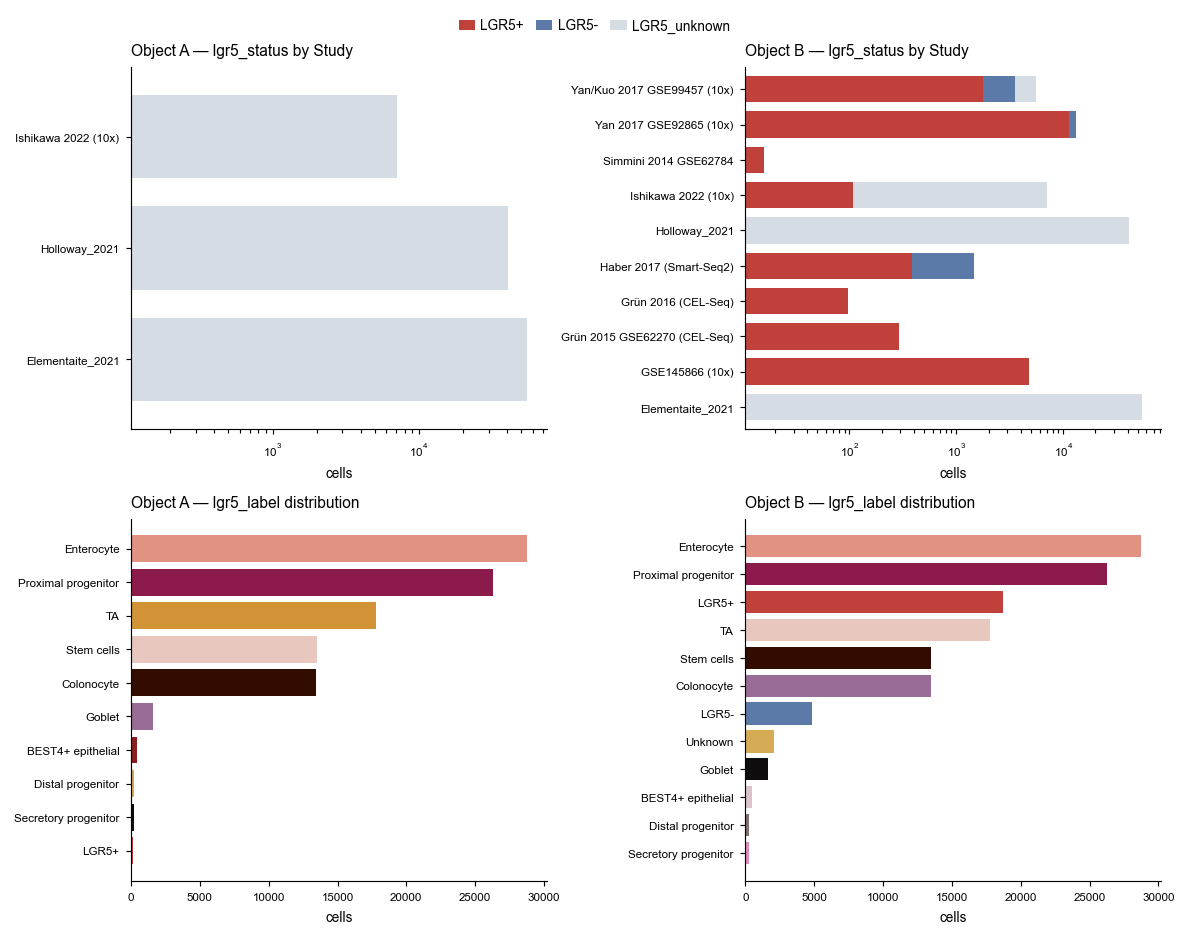

saved /Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis/analysis_enhanced/figures/0_inputs/lgr5_status_and_label_audit.pdf
saved /Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis/analysis_enhanced/figures/0_inputs/lgr5_status_and_label_audit.png


In [7]:
from matplotlib.patches import Patch

STATUS_COLORS = {
    'LGR5+': '#C0413B',          # GrandBudapest red
    'LGR5-': '#5B7AA8',          # cool blue
    'LGR5_unknown': '#D6DCE4',   # BG_GRAY
}

fig, axes = plt.subplots(2, 2, figsize=(8.5, 6.5))

# Panel A: Object A — lgr5_status counts by Study_name
ax = axes[0, 0]
ct = (obj_a.obs.groupby(['Study_name', 'lgr5_status'], observed=True).size()
             .unstack(fill_value=0)
             .reindex(columns=['LGR5+', 'LGR5-', 'LGR5_unknown'], fill_value=0))
ct.plot(kind='barh', stacked=True, ax=ax, color=[STATUS_COLORS[c] for c in ct.columns], width=0.75, legend=False)
ax.set_xlabel('cells')
ax.set_ylabel('')
ax.set_title('Object A — lgr5_status by Study', fontsize=8, loc='left')
ax.set_xscale('log')

# Panel B: Object B — lgr5_status counts by Study_name
ax = axes[0, 1]
ct = (obj_b.obs.groupby(['Study_name', 'lgr5_status'], observed=True).size()
             .unstack(fill_value=0)
             .reindex(columns=['LGR5+', 'LGR5-', 'LGR5_unknown'], fill_value=0))
ct.plot(kind='barh', stacked=True, ax=ax, color=[STATUS_COLORS[c] for c in ct.columns], width=0.75, legend=False)
ax.set_xlabel('cells')
ax.set_ylabel('')
ax.set_title('Object B — lgr5_status by Study', fontsize=8, loc='left')
ax.set_xscale('log')

# Panel C: Object A lgr5_label value counts
ax = axes[1, 0]
vc = obj_a.obs['lgr5_label'].value_counts()
label_colors = [STATUS_COLORS.get(l, WES_PALETTE[i % len(WES_PALETTE)]) for i, l in enumerate(vc.index)]
ax.barh(vc.index.astype(str), vc.values, color=label_colors)
ax.set_xlabel('cells')
ax.set_title('Object A — lgr5_label distribution', fontsize=8, loc='left')
ax.invert_yaxis()

# Panel D: Object B lgr5_label value counts
ax = axes[1, 1]
vc = obj_b.obs['lgr5_label'].value_counts()
label_colors = [STATUS_COLORS.get(l, WES_PALETTE[i % len(WES_PALETTE)]) for i, l in enumerate(vc.index)]
ax.barh(vc.index.astype(str), vc.values, color=label_colors)
ax.set_xlabel('cells')
ax.set_title('Object B — lgr5_label distribution', fontsize=8, loc='left')
ax.invert_yaxis()

# Shared legend for panels A and B
handles = [Patch(facecolor=STATUS_COLORS[s], label=s) for s in ['LGR5+', 'LGR5-', 'LGR5_unknown']]
fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=7)

fig.tight_layout()
out_pdf = FIG_DIR / 'lgr5_status_and_label_audit.pdf'
out_png = FIG_DIR / 'lgr5_status_and_label_audit.png'
fig.savefig(out_pdf)
fig.savefig(out_png, dpi=300)
plt.show()
print(f'saved {out_pdf}\nsaved {out_png}')

## 8. Sanity table — LGR5+ cells per study (Object B)


In [8]:
summary = (obj_b.obs.groupby(['species', 'Study_name', 'lgr5_status'], observed=True).size()
                  .unstack(fill_value=0)
                  .reindex(columns=['LGR5+', 'LGR5-', 'LGR5_unknown'], fill_value=0))
summary['total'] = summary.sum(axis=1)
summary_csv = FIG_DIR / 'lgr5_status_per_study.csv'
summary.to_csv(summary_csv)
print('Saved', summary_csv)
summary

Saved /Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis/analysis_enhanced/figures/0_inputs/lgr5_status_per_study.csv


lgr5_status                           LGR5+  LGR5-  LGR5_unknown  total
species Study_name                                                     
human   Elementaite_2021                  0      0         54600  54600
        Holloway_2021                     0      0         40757  40757
        Ishikawa 2022 (10x)             108      0          6995   7103
mouse   GSE145866 (10x)                4815      0             0   4815
        Grün 2015 GSE62270 (CEL-Seq)    288      0             0    288
        Grün 2016 (CEL-Seq)              96      0             0     96
        Haber 2017 (Smart-Seq2)         384   1069             0   1453
        Simmini 2014 GSE62784            16      0             0     16
        Yan 2017 GSE92865 (10x)       11268   1979             0  13247
        Yan/Kuo 2017 GSE99457 (10x)    1764   1756          2050   5570

## 9. Done

All downstream notebooks (5_comparisons, 6_degs, 7_similarity, 8_summary) can now use:
- `lgr5_status` ∈ {`LGR5+`, `LGR5-`, `LGR5_unknown`} for population-level grouping.
- `lgr5_label` for scANVI / scPoli semi-supervised training on Object B.
